In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../../..'))
from src.models.v3.n_gram_network import Tokenizer, NGramNetwork
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
%matplotlib inline

In [2]:
# Hyperparameters

context_size = 3
embedding_vector_size = 8
w1_out = 256
batch_size = 64
iterations = 64_000

q = 10
# t = 20_000 <- tested hyperparam

Dev set (5940 params):
- best t with f(0)=0.1 : 3_000

Test set (47524 params):
- best t with f(0)=0.1 and 64_000 iterations : 32_000, that is where it stops converging to around 2.1 

This is kind of a guess, but it seems that you need t at around 2/3 of the parameter count
Could be completely wrong tho, and I will stop experimenting on the first n gram network,
and go on to version 2.í

In [3]:
# Initializations for network

data_path = '../../../src/data/normalized/en_cities.txt'
tokenizer = Tokenizer(data_path)

In [4]:
def test(t: int) -> float:
    # Init and train network
    network = NGramNetwork(context_size, tokenizer, data_path, embedding_vector_size, w1_out)
    network.train(batch_size, iterations, lambda i: q ** (-i/t - 1), print_out=False, use_dev_set=False)
    
    # Return test set loss
    return network.evaluate_test_set()
    
    

In [5]:
values = []
losses = []
times = []

In [10]:
# Test w1_outs from 8 to 512:
# values = []
# losses = []
# times = []

for t in range(37_000, 64_000+1, 1000):
    start_time = time.perf_counter()
    
    loss = test(t)

    elapsed_time = time.perf_counter() - start_time
    
    values.append(t)
    losses.append(loss)
    times.append(elapsed_time)
    
    print(t, '-->', loss)

37000 --> 2.111509323120117
38000 --> 2.1071622371673584
39000 --> 2.0985817909240723
40000 --> 2.099807024002075
41000 --> 2.0978169441223145
42000 --> 2.099473714828491
43000 --> 2.1033544540405273
44000 --> 2.1005377769470215
45000 --> 2.108713388442993
46000 --> 2.1089136600494385
47000 --> 2.1109683513641357
48000 --> 2.0935845375061035
49000 --> 2.095562219619751
50000 --> 2.099414348602295
51000 --> 2.094334363937378
52000 --> 2.1182496547698975
53000 --> 2.0989513397216797
54000 --> 2.1166157722473145
55000 --> 2.1052536964416504
56000 --> 2.1009085178375244
57000 --> 2.1027731895446777
58000 --> 2.1043124198913574
59000 --> 2.085681438446045
60000 --> 2.1047873497009277
61000 --> 2.1081552505493164
62000 --> 2.1046690940856934
63000 --> 2.094973564147949
64000 --> 2.0987331867218018


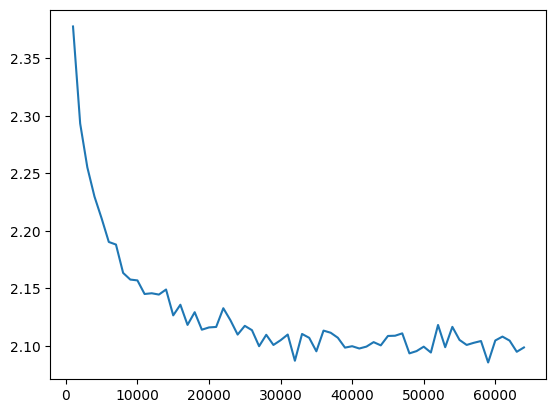

In [11]:
plt.plot(values, losses)
plt.show()

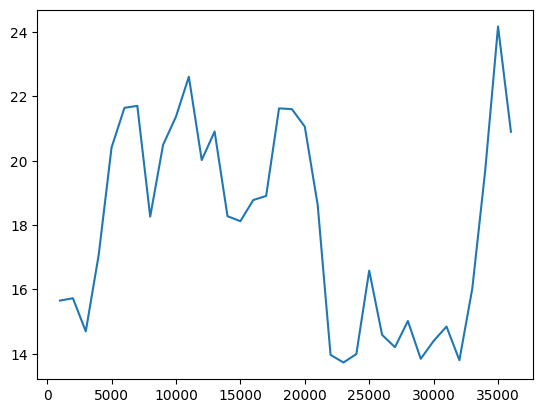

In [8]:
plt.plot(values, times)
plt.show()

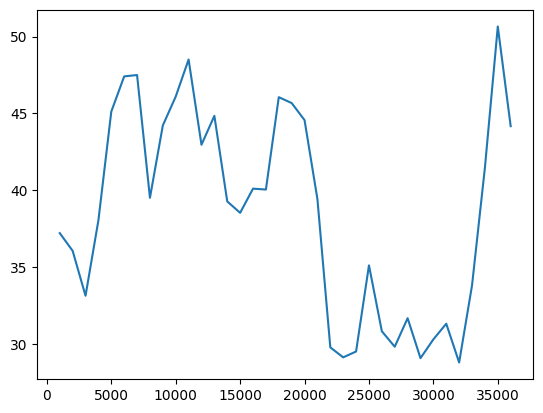

In [9]:
x = np.array(losses) * np.array(times)
plt.plot(values, x)
plt.show()